# Лабораторная работа №1 — Twitter US Airline Sentiment

**Тема:** низкоуровневый анализ, очистка, нормализация, строковые метрики и статистическая языковая модель.  
**Источник:** [CrowdFlower / Kaggle](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment); данные — твиты об авиакомпаниях США, размеченные как `negative`, `neutral`, `positive`. Лицензия набора — CC BY-NC-SA 4.0. CSV скачивается в первой кодовой ячейке с общедоступного [зеркала](https://github.com/satyajeetkrjha/kaggle-Twitter-US-Airline-Sentiment-/blob/master/Tweets.csv).

Ноутбук выполняется сверху вниз. Все статистики корпуса вычисляются на **Train**; Test используется только при расчёте перплексии. Графики и выводы сохранены прямо в выполненном ноутбуке.

## 1. Загрузка и стратифицированное разбиение

Загружаем реальный `Tweets.csv`, берём `text` как текст и `airline_sentiment` как целевой класс. Сохраняем фиксированное разбиение 80/20.

In [2]:
from pathlib import Path
from urllib.request import urlretrieve
import re
import html
import math
import random
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATA_URL = "https://raw.githubusercontent.com/satyajeetkrjha/kaggle-Twitter-US-Airline-Sentiment-/master/Tweets.csv"
DATA_PATH = Path("data/Tweets.csv")
DATA_PATH.parent.mkdir(exist_ok=True)
if not DATA_PATH.exists():
    urlretrieve(DATA_URL, DATA_PATH)

frame = pd.read_csv(DATA_PATH, usecols=["text", "airline_sentiment"]).dropna()
train, test = train_test_split(frame, test_size=0.2, random_state=42,
                               stratify=frame["airline_sentiment"])
print("Файл:", DATA_PATH, "| Всего:", len(frame), "| Train:", len(train), "| Test:", len(test))
pd.DataFrame({"Train": train.airline_sentiment.value_counts(),
              "Test": test.airline_sentiment.value_counts()}).sort_index()

Файл: data/Tweets.csv | Всего: 14640 | Train: 11712 | Test: 2928


,Train,Test
airline_sentiment,,
negative,7343,1835
neutral,2479,620
positive,1890,473


## 2. Структура обучающей части

Длина в словах считается на исходном тексте через регулярное выражение для английских слов (с апострофами), длина в символах — встроенной `len`. Стоп-слова берём из явного перечня, чтобы график не зависел от дополнительных скачиваемых корпусов. Стоп-слова **не удаляются** из языковой модели: они помогают сохранять грамматику.

Документов Train: 11712; среднее слов: 17.65; среднее символов: 103.92


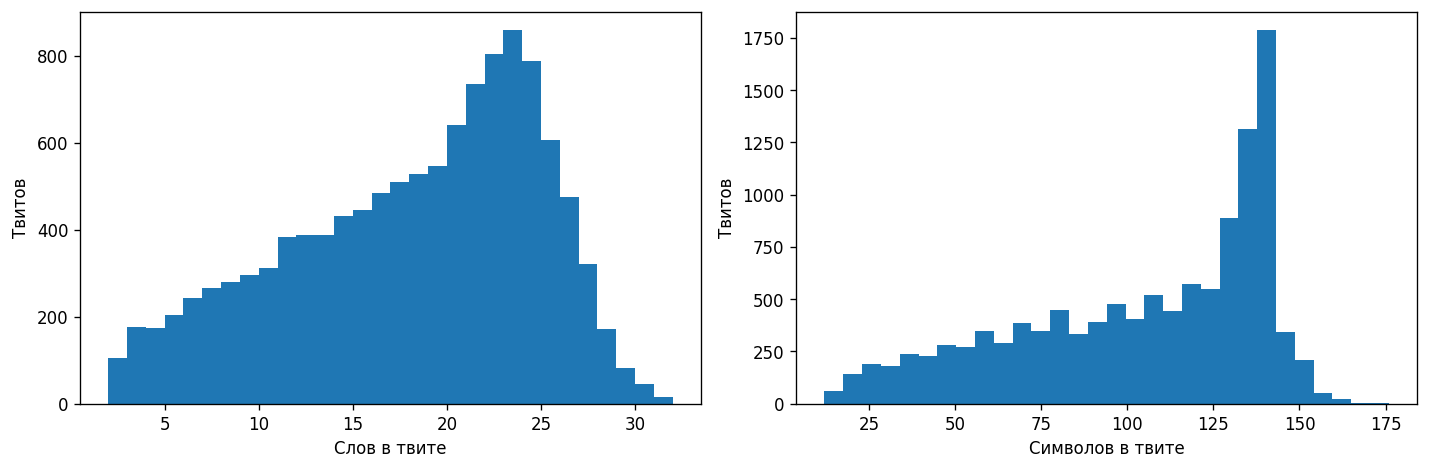

In [4]:
train_texts = train["text"].tolist()
test_texts = test["text"].tolist()
WORD = re.compile(r"[a-z]+(?:['’][a-z]+)?", re.I)
length_words = [len(WORD.findall(t)) for t in train_texts]
length_chars = [len(t) for t in train_texts]
print(f"Документов Train: {len(train_texts)}; среднее слов: {sum(length_words)/len(length_words):.2f}; "
      f"среднее символов: {sum(length_chars)/len(length_chars):.2f}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(length_words, bins=30)
axes[0].set(xlabel="Слов в твите", ylabel="Твитов")
axes[1].hist(length_chars, bins=30)
axes[1].set(xlabel="Символов в твите", ylabel="Твитов")
fig.tight_layout()
plt.show()

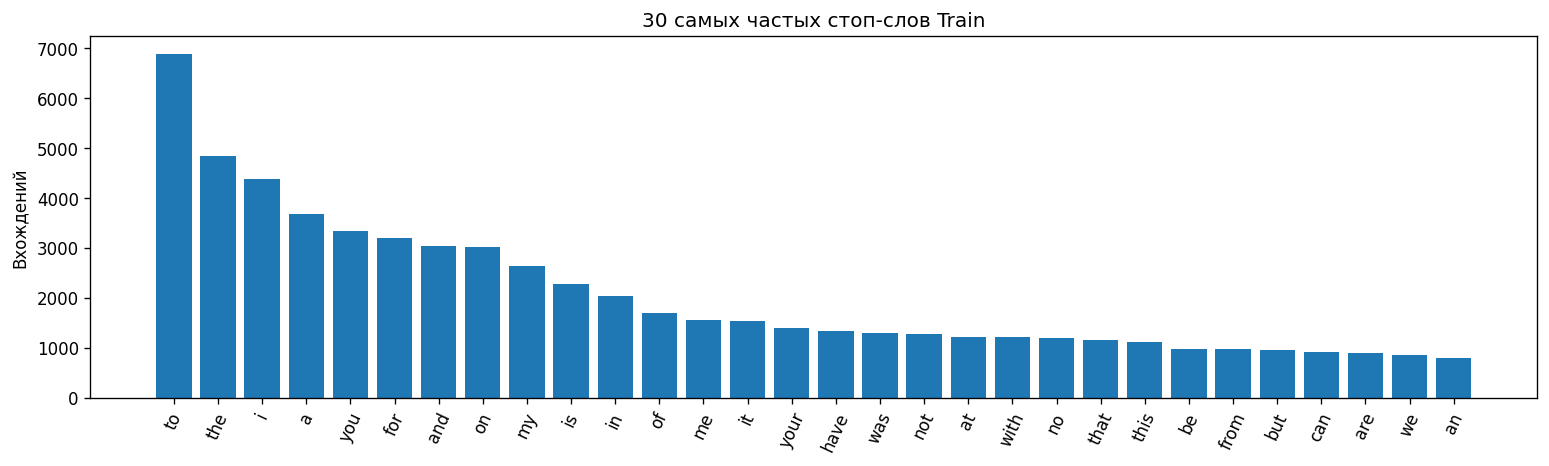

,Стоп-слово,Частота
0,to,6889
1,the,4833
2,i,4380
3,a,3673
4,you,3339
5,for,3191
6,and,3032
7,on,3018
8,my,2641
9,is,2274


In [5]:
STOP_WORDS = set("the a an and or but to of in on at for with is are was were be been i you we they it my your our this that have has had do does did not no so as from by me us he she am will can if just all up what when how why who".split())
stop_counts = Counter(word.lower() for text in train_texts for word in WORD.findall(text)
                      if word.lower() in STOP_WORDS)
top_stops = stop_counts.most_common(30)
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar([word for word, _ in top_stops], [count for _, count in top_stops])
ax.tick_params(axis="x", rotation=65)
ax.set(ylabel="Вхождений", title="30 самых частых стоп-слов Train")
fig.tight_layout()
plt.show()
pd.DataFrame(top_stops, columns=["Стоп-слово", "Частота"]).head(10)

## 3. Шум, характерный для твитов

Отдельно считаем документы с адресами, упоминаниями, хештегами, HTML-сущностями, эмодзи и числами. Несколько видов шума могут встречаться в одном твите. Количество упоминаний особенно велико: твиты часто начинаются с обращения к авиакомпании.

In [7]:
URL = re.compile(r"(?:https?://|www\.)\S+", re.I)
EMAIL = re.compile(r"\b[\w.+-]+@[\w.-]+\.[a-z]{2,}\b", re.I)
MENTION = re.compile(r"(?<!\w)@[A-Za-z0-9_]+")
HASHTAG = re.compile(r"(?<!\w)#[A-Za-z0-9_]+")
NUMBER = re.compile(r"\b\d+(?:[.,:]\d+)*\b")
HTML_ENTITY = re.compile(r"&(?:\#\d+|\#x[0-9a-f]+|[a-z]+);", re.I)
EMOJI = re.compile(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]")
noise_patterns = {"URL": URL, "Упоминания": MENTION, "Хештеги": HASHTAG,
                  "HTML-сущности": HTML_ENTITY, "Эмодзи": EMOJI, "Числа": NUMBER,
                  "Email": EMAIL}
pd.DataFrame([{"Шум": name,
               "Твитов Train": sum(bool(pattern.search(t)) for t in train_texts),
               "Пример": next((t[:100] for t in train_texts if pattern.search(t)), "—")}
              for name, pattern in noise_patterns.items()])

,Шум,Твитов Train,Пример
0,URL,929,"See you in ATL! “@SouthwestAir: Congrats to our #DestinationDragons winners! Ready, Atlanta? http://"
1,Упоминания,11712,@united what would it cost
2,Хештеги,1905,"@SouthwestAir not frustrated, just an idea! Great crew. Thanks! #happycustomer"
3,HTML-сущности,583,"@JetBlue big shoutout to the crews on 2017 Bos&gt;jfk &amp; 486 jfk&gt;roc, &amp; gate crews at c19"
4,Эмодзи,379,@SouthwestAir replacing @vitaminwater with beer! Bravo!👏👏 Cheers! 🍻🍻 @Leinenkugels @DosEquis @FatTir
5,Числа,3360,@USAirways Used 2 get emails 1) pre-purchase a snack and 2) when time to check in. Got neither 4 tom
6,Email,11,@AmericanAir please email me at temorris2010@hotmail.com. willing to discuss my experience &amp; giv


## 4. Очистка и токенизация

Правила применяются последовательно: декодируем HTML-сущности; URL, почту, упоминания, хештеги, числа и эмодзи заменяем **разными** токенами. Сохраняем слова, апострофы и часть пунктуации, а также границы `<s>` и `</s>`. Текст хештегов заменяется целиком: это упрощает словарь, хотя теряется информация об их содержании. В частности, мы не применяем правило «удалить всё, кроме букв».

In [9]:
TOKEN = re.compile(r"\[[A-Z]+\]|[a-z]+(?:['’][a-z]+)?|[.!?]+|[,;:]", re.I)

def clean(text):
    text = html.unescape(text)
    text = URL.sub(" [URL] ", text)
    text = EMAIL.sub(" [EMAIL] ", text)
    text = MENTION.sub(" [USER] ", text)
    text = HASHTAG.sub(" [TAG] ", text)
    text = EMOJI.sub(" [EMOJI] ", text)
    text = NUMBER.sub(" [NUM] ", text)
    tokens = TOKEN.findall(text.lower())
    return ["<s>", *(t.upper() if t.startswith("[") else t for t in tokens), "</s>"]

train_tokens = [clean(t) for t in train_texts]
test_tokens = [clean(t) for t in test_texts]
for raw, tokens in list(zip(train_texts, train_tokens))[:5]:
    print("Исходный:", raw, "\nТокены:  ", tokens, "\n")

Исходный: @united what would it cost 
Токены:   ['<s>', '[USER]', 'what', 'would', 'it', 'cost', '</s>'] 

Исходный: @USAirways Used 2 get emails 1) pre-purchase a snack and 2) when time to check in. Got neither 4 tomorrow's trip. Do they not get sent now? 
Токены:   ['<s>', '[USER]', 'used', '[NUM]', 'get', 'emails', '[NUM]', 'pre', 'purchase', 'a', 'snack', 'and', '[NUM]', 'when', 'time', 'to', 'check', 'in', '.', 'got', 'neither', '[NUM]', "tomorrow's", 'trip', '.', 'do', 'they', 'not', 'get', 'sent', 'now', '?', '</s>'] 

Исходный: @united no, it was 2 flight Cancelled Flightlations (one due to weather, one mechanical) paid own hotel, bag held in transfer. No voucher/compensation 
Токены:   ['<s>', '[USER]', 'no', ',', 'it', 'was', '[NUM]', 'flight', 'cancelled', 'flightlations', 'one', 'due', 'to', 'weather', ',', 'one', 'mechanical', 'paid', 'own', 'hotel', ',', 'bag', 'held', 'in', 'transfer', '.', 'no', 'voucher', 'compensation', '</s>'] 

Исходный: @SouthwestAir not frustrated

## 5. Стемминг и лемматизация

Сравниваем размеры словарей **буквенных** токенов Train. Для английского используем Porter и WordNet; части речи определяем теггером NLTK. Они определяются у слов без контекста, поэтому отдельные леммы могут быть неточными. Служебные метки и пунктуация исключены из этого сравнения.

При первом запуске необходимые корпуса NLTK скачиваются из его официального репозитория в `~/nltk_data`.

In [11]:
import zipfile
import nltk
from nltk.corpus import wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer

for category, name in (("corpora", "wordnet"),
                       ("taggers", "averaged_perceptron_tagger_eng")):
    archive = Path.home() / "nltk_data" / category / f"{name}.zip"
    extracted = archive.parent / name
    if not archive.exists() and not extracted.exists():
        archive.parent.mkdir(parents=True, exist_ok=True)
        url = f"https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/{category}/{name}.zip"
        urlretrieve(url, archive)
    if category == "taggers" and not extracted.exists():
        with zipfile.ZipFile(archive) as source:
            source.extractall(archive.parent)
wordnet.ensure_loaded()

words = sorted({t for doc in train_tokens for t in doc if t.isalpha()})
porter, lemmatizer = PorterStemmer(), WordNetLemmatizer()
pos_map = {"J": wordnet.ADJ, "V": wordnet.VERB, "N": wordnet.NOUN, "R": wordnet.ADV}
tagged = nltk.pos_tag(words)
stemmed = {porter.stem(w) for w in words}
lemmatized = {lemmatizer.lemmatize(w, pos_map.get(pos[0], wordnet.NOUN)) for w, pos in tagged}
pd.DataFrame({"Вариант": ["До нормализации", "После стемминга", "После лемматизации"],
              "Уникальных токенов": [len(words), len(stemmed), len(lemmatized)]})

,Вариант,Уникальных токенов
0,До нормализации,8808
1,После стемминга,6480
2,После лемматизации,7091


Стемминг объединяет больше словоформ, но создаёт искусственные основы; леммы читаются лучше. Для биграммной модели ниже оставляем исходные очищенные словоформы, чтобы не разрушать наблюдаемые соседства слов.

## 6. Расстояние Левенштейна и кандидаты на опечатки

Реализация использует две строки динамического программирования: память $O(\min(|a|,|b|))$. Поиск не перебирает все пары словаря: индекс по вариантам с удалением одной или двух букв даёт кандидатов, затем точное расстояние подтверждается собственной функцией. Сопоставляем редкие слова (1–2 раза) с частыми (не менее 5); близость написания сама по себе не доказывает опечатку.

In [14]:
def levenshtein(a, b):
    if len(a) < len(b):
        a, b = b, a
    previous = list(range(len(b) + 1))
    for i, char_a in enumerate(a, 1):
        current = [i]
        for j, char_b in enumerate(b, 1):
            current.append(min(previous[j] + 1, current[-1] + 1,
                               previous[j - 1] + (char_a != char_b)))
        previous = current
    return previous[-1]

assert levenshtein("kitten", "sitting") == 3
assert levenshtein("fligt", "flight") == 1
assert levenshtein("", "air") == 3

frequencies = Counter(t for doc in train_tokens for t in doc[1:-1])
index = defaultdict(set)
for word in (w for w in frequencies if w.isalpha() and 4 <= len(w) <= 18):
    keys = {word}
    for i in range(len(word)):
        one = word[:i] + word[i + 1:]
        keys.add(one)
        for j in range(len(one)):
            keys.add(one[:j] + one[j + 1:])
    for key in keys:
        index[key].add(word)

candidate_pairs = set()
for group in index.values():
    rare = [w for w in group if frequencies[w] <= 2]
    common = [w for w in group if frequencies[w] >= 5]
    for a in rare:
        for b in common:
            if a != b and abs(len(a) - len(b)) <= 2:
                candidate_pairs.add((a, b))

pairs = [(levenshtein(a, b), a, b, frequencies[a], frequencies[b]) for a, b in candidate_pairs]
top_pairs = sorted((row for row in pairs if row[0] in (1, 2)),
                   key=lambda row: (row[0], -row[4], row[3], row[1]))[:10]
pd.DataFrame(top_pairs, columns=["Расстояние", "Редкое слово", "Частое слово",
                                  "Частота редкого", "Частота частого"])

,Расстояние,Редкое слово,Частое слово,Частота редкого,Частота частого
0,1,flightn,flight,1,3136
1,1,fligt,flight,1,3136
2,1,fllight,flight,1,3136
3,1,slight,flight,1,3136
4,1,sour,your,1,1390
5,1,yout,your,1,1390
6,1,cave,have,1,1342
7,1,fave,have,2,1342
8,1,wave,have,2,1342
9,1,wiyh,with,1,1215


Среди пар есть как реальные опечатки (`fligt` → `flight`), так и разные слова (`slight` и `flight`). Перестановка соседних букв не является одним действием в обычном расстоянии Левенштейна; здесь учитываются только вставка, удаление и замена.

## 7. Биграммная модель и словарь

Словарь строится **только по Train**: токены с частотой меньше 2 заменяются на `[UNK]` ещё при обучении, чтобы модель получила примеры этого события. Test отображается тем же словарём. `<s>` — контекст, `</s>` — предсказываемый конец документа. Счётчики соседних токенов образуют марковскую цепь первого порядка.

In [17]:
class BigramModel:
    def __init__(self, documents, min_count=2):
        counts = Counter(t for doc in documents for t in doc[1:-1])
        self.vocabulary = {t for t, count in counts.items() if count >= min_count}
        self.vocabulary.update({"</s>", "[UNK]"})
        self.transitions = defaultdict(Counter)
        self.contexts = Counter()
        for document in documents:
            mapped = self.map_document(document)
            for a, b in zip(mapped, mapped[1:]):
                self.transitions[a][b] += 1
                self.contexts[a] += 1

    def map_document(self, document):
        return ["<s>", *(t if t in self.vocabulary else "[UNK]" for t in document[1:-1]), "</s>"]

    def perplexity(self, documents, alpha=0):
        log_likelihood, count_tokens = 0.0, 0
        for doc in documents:
            mapped = self.map_document(doc)
            for a, b in zip(mapped, mapped[1:]):
                frequency = self.transitions[a][b]
                context = self.contexts[a]
                if alpha == 0 and frequency == 0:
                    return math.inf
                probability = ((frequency + alpha) / (context + alpha * len(self.vocabulary))
                               if alpha else frequency / context)
                log_likelihood += math.log(probability)
                count_tokens += 1
        return math.exp(-log_likelihood / count_tokens)

    def generate(self, rng, max_tokens=30):
        current, tokens = "<s>", ["<s>"]
        for _ in range(max_tokens):
            choices = self.transitions[current]
            if not choices:
                break
            current = rng.choices(list(choices), weights=list(choices.values()))[0]
            tokens.append(current)
            if current == "</s>":
                break
        return " ".join(tokens)

model = BigramModel(train_tokens)
unknown_test = sum(t not in model.vocabulary for doc in test_tokens for t in doc[1:-1])
print("Размер словаря предсказываемых токенов:", len(model.vocabulary))
print("Токенов Test, заменённых на [UNK]:", unknown_test)
print("Частые продолжения <s>:", model.transitions["<s>"].most_common(8))

Размер словаря предсказываемых токенов: 5027
Токенов Test, заменённых на [UNK]: 1728
Частые продолжения <s>: [('[USER]', 11442), ('.', 83), ('[EMOJI]', 11), ('[UNK]', 9), ('thanks', 9), ('i', 8), ('stop', 6), ('why', 6)]


## 8. Сглаживание и перплексия на Test

Без сглаживания $P(w\mid c)=C(c,w)/C(c)$, отсутствующая биграмма имеет вероятность 0. С аддитивным сглаживанием Лапласа $P(w\mid c)=(C(c,w)+1)/(C(c)+|V|)$, где $V$ — словарь предсказываемых токенов, включая `[UNK]` и `</s>`.

Считаем $\operatorname{PPL}=\exp(-\sum_{i=1}^{M}\log P(w_i\mid w_{i-1})/M)$ по **всем** токенам Test, включая концы документов; логарифмы предотвращают переполнение произведения вероятностей.

In [19]:
ppl_plain = model.perplexity(test_tokens, alpha=0)
ppl_laplace = model.perplexity(test_tokens, alpha=1)
pd.DataFrame({"Режим": ["Без сглаживания", "Лаплас (+1)"],
              "Перплексия Test": [ppl_plain, ppl_laplace]})

,Режим,Перплексия Test
0,Без сглаживания,inf
1,Лаплас (+1),422.932748


**Вывод.** Без сглаживания хотя бы одна невиданная биграмма делает вероятность всего Test нулевой: $\log 0=-\infty$, поэтому перплексия равна $\infty$. Лаплас даёт положительную вероятность каждому токену словаря и конечное значение. Сравнение конечного числа с бесконечностью подтверждает корректную обработку неизвестных переходов, но само по себе не доказывает хорошее качество текстов. Сглаживание +1 также распределяет много массы по большому словарю.

## 9. Генерация пяти текстов

Каждая траектория начинается с `<s>`; следующие токены выбираются случайно с весами по наблюдённым частотам переходов. Генерация останавливается на `</s>` либо после 30 токенов. Фиксированные начальные состояния делают примеры воспроизводимыми.

In [22]:
generated = [model.generate(random.Random(42 + i), max_tokens=30) for i in range(5)]
for i, sentence in enumerate(generated, 1):
    print(f"{i}. {sentence}")

1. <s> [USER] not the flight attendant at several times . thanks . any way to dm ? </s>
2. <s> [USER] only to talk to </s>
3. <s> [USER] [TAG] flightr and delay ? </s>
4. <s> [USER] in the [UNK] to check in the last minute delay this is charging for the u this is it wants fucking service rep wouldn't stow not cool !!! </s>
5. <s> [USER] also add it is very bad these prices thru security logic ? </s>


**Оценка.** В образцах встречаются локально правдоподобные сочетания вроде `the flight`, но последовательность часто перескакивает между темами, повторяет короткие фразы и теряет согласованность на длине твита. Служебные `[USER]`, `[TAG]`, `[UNK]` ухудшают читаемость. Биграмма учитывает только предыдущий токен, поэтому её грамматическая связность и смысловая адекватность ограничены. На этом наборе твитов она служит базовым сравнением, а не полноценным генератором осмысленных отзывов.